In [1]:
!pip install pandas numpy scikit-learn joblib matplotlib seaborn

In [2]:
import re
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
uploaded = files.upload()

Saving spam.csv to spam.csv


In [4]:
file_name = list(uploaded.keys())[0]
file_name

'spam.csv'

In [5]:
def load_sms_dataset(file_path):
    try:
        df = pd.read_csv(file_path, encoding="latin-1")

        if "v1" in df.columns and "v2" in df.columns:
            df = df[["v1", "v2"]]
            df.columns = ["label", "message"]
            return df

        if "label" in df.columns and "message" in df.columns:
            df = df[["label", "message"]]
            return df

        if len(df.columns) >= 2:
            df = df.iloc[:, :2]
            df.columns = ["label", "message"]
            return df

    except Exception:
        pass

    df = pd.read_csv(file_path, sep="\t", header=None, names=["label", "message"])
    return df


df = load_sms_dataset(file_name)

print("5 data pertama:")
display(df.head())

print("Jumlah baris dan kolom:", df.shape)

print("Nama kolom:")
print(df.columns)

5 data pertama:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Jumlah baris dan kolom: (5572, 2)
Nama kolom:
Index(['label', 'message'], dtype='object')


In [6]:
print("Missing value:")
print(df.isnull().sum())

print("\nJumlah duplikat:")
print(df.duplicated().sum())

print("\nDistribusi label sebelum cleaning:")
print(df["label"].value_counts())

Missing value:
label      0
message    0
dtype: int64

Jumlah duplikat:
403

Distribusi label sebelum cleaning:
label
ham     4825
spam     747
Name: count, dtype: int64


In [7]:
df = df.dropna()
df = df.drop_duplicates()

df["label"] = df["label"].str.lower().str.strip()
df["message"] = df["message"].astype(str)

print("Jumlah data setelah cleaning:", df.shape)

print("\nDistribusi label setelah cleaning:")
print(df["label"].value_counts())

Jumlah data setelah cleaning: (5169, 2)

Distribusi label setelah cleaning:
label
ham     4516
spam     653
Name: count, dtype: int64


In [8]:
def clean_text(text):
    text = str(text).lower()

    # hapus URL
    text = re.sub(r"http\S+|www\S+", " ", text)

    # hapus email
    text = re.sub(r"\S+@\S+", " ", text)

    # hapus angka dan simbol
    text = re.sub(r"[^a-z\s]", " ", text)

    # hapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()

    # hapus stopword
    tokens = text.split()
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS]

    return " ".join(tokens)


df["clean_message"] = df["message"].apply(clean_text)

display(df[["message", "clean_message", "label"]].head(10))

,message,clean_message,label
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...,ham
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,spam
3,U dun say so early hor... U c already then say...,u dun say early hor u c say,ham
4,"Nah I don't think he goes to usf, he lives aro...",nah don t think goes usf lives,ham
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling s week s word d like fun t...,spam
6,Even my brother is not like to speak with me. ...,brother like speak treat like aids patent,ham
7,As per your request 'Melle Melle (Oru Minnamin...,request melle melle oru minnaminunginte nurung...,ham
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...,spam
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...,spam


In [9]:
X = df["clean_message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 4135
Jumlah data testing: 1034


In [10]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Ukuran fitur TF-IDF training:", X_train_tfidf.shape)
print("Ukuran fitur TF-IDF testing:", X_test_tfidf.shape)

Ukuran fitur TF-IDF training: (4135, 5000)
Ukuran fitur TF-IDF testing: (1034, 5000)


In [11]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

print("Training selesai.")

Training selesai.


In [12]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Akurasi:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi: 0.9661508704061895

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



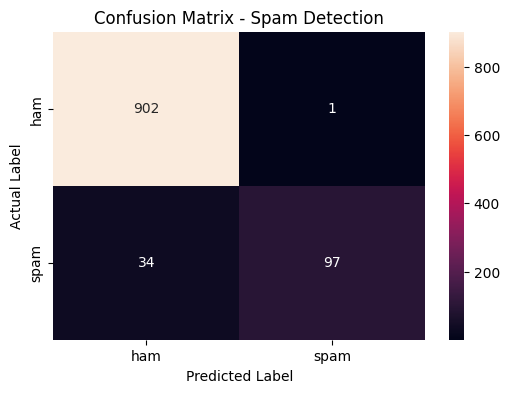

In [13]:
labels = ["ham", "spam"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Spam Detection")
plt.show()

In [14]:
def predict_message(message):
    clean_message = clean_text(message)
    vectorized_message = vectorizer.transform([clean_message])

    prediction = model.predict(vectorized_message)[0]
    probabilities = model.predict_proba(vectorized_message)[0]

    class_labels = model.classes_
    confidence = probabilities.max()

    return {
        "message": message,
        "clean_message": clean_message,
        "prediction": prediction,
        "confidence": confidence,
        "probabilities": dict(zip(class_labels, probabilities))
    }


test_1 = "Congratulations! You won a free prize. Click this link now!"
test_2 = "Hey, are we still meeting tonight?"

print(predict_message(test_1))
print(predict_message(test_2))

{'message': 'Congratulations! You won a free prize. Click this link now!', 'clean_message': 'congratulations won free prize click link', 'prediction': np.str_('spam'), 'confidence': np.float64(0.8615741213458216), 'probabilities': {np.str_('ham'): np.float64(0.13842587865417988), np.str_('spam'): np.float64(0.8615741213458216)}}
{'message': 'Hey, are we still meeting tonight?', 'clean_message': 'hey meeting tonight', 'prediction': np.str_('ham'), 'confidence': np.float64(0.9957444654160416), 'probabilities': {np.str_('ham'): np.float64(0.9957444654160416), np.str_('spam'): np.float64(0.004255534583958448)}}


In [15]:
joblib.dump(model, "spam_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [17]:
files.download("spam_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>